<a href="https://colab.research.google.com/github/aayushijain28/aayushijain_ml2_lab/blob/main/experiment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-09-23 06:38:37--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  58.89K  --.-KB/s    in 0.002s  

2026-09-23 06:38:37 (26.4 MB/s) - ‘train.csv’ saved [60302/60302]

Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cuming

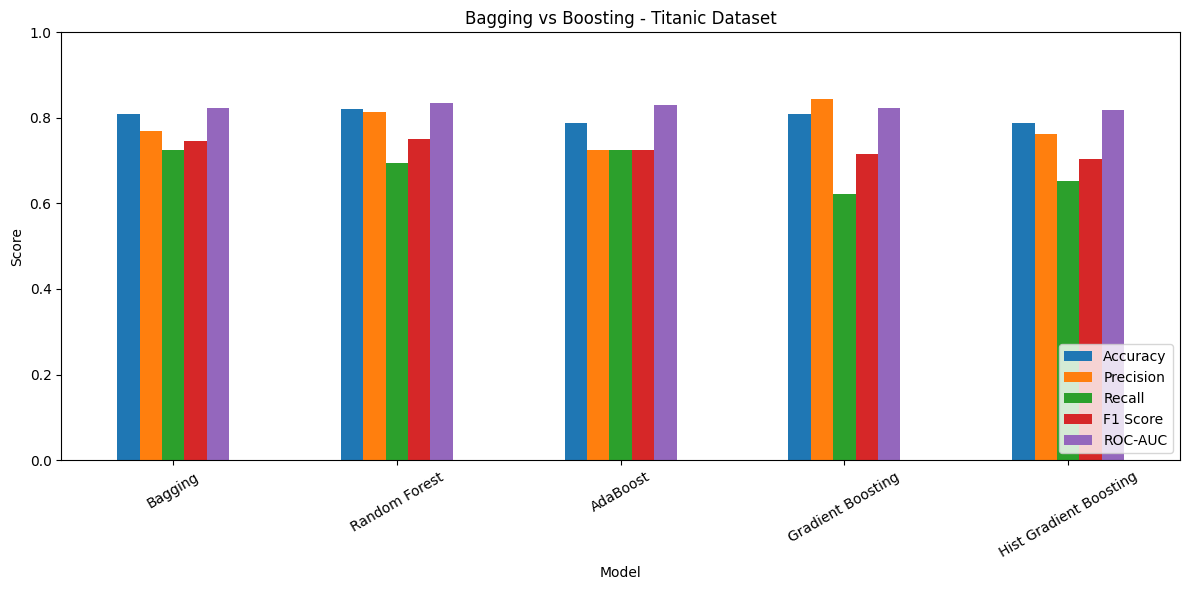

In [13]:
# ============================================================
# TITANIC SURVIVAL CLASSIFICATION USING BAGGING & BOOSTING
# ============================================================

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. READ DATASET
# ------------------------------------------------------------

# The kagglehub.dataset_download function appears to be returning a Kaggle-specific
# path ('/kaggle/input/titanic') which is not accessible in Colab.
# To ensure the dataset is available, we'll download train.csv directly.
!wget -O train.csv https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 2. SELECT FEATURES AND TARGET
# ------------------------------------------------------------

# Target variable
y = df["Survived"]

# Drop columns that are not directly useful for this basic model
# PassengerId is an identifier.
# Name and Ticket have high-cardinality text.
# Cabin has many missing values.
X = df.drop(
    columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"]
)

print("\nFeatures:")
print(X.columns)


# ------------------------------------------------------------
# 3. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]


# ------------------------------------------------------------
# 4. PREPROCESSING
# ------------------------------------------------------------

# Numerical columns:
# Replace missing values with median
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical columns:
# Replace missing values with most frequent value
# Then convert categories to numerical dummy variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# ------------------------------------------------------------
# 5. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------------------
# 6. DEFINE BAGGING MODELS
# ------------------------------------------------------------

bagging_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            BaggingClassifier(
                estimator=DecisionTreeClassifier(
                    max_depth=None,
                    random_state=42
                ),
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# 7. DEFINE BOOSTING MODELS
# ------------------------------------------------------------

adaboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            AdaBoostClassifier(
                n_estimators=100,
                learning_rate=0.5,
                random_state=42
            )
        )
    ]
)


gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)


hist_gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                max_iter=100,
                learning_rate=0.05,
                max_leaf_nodes=15,
                random_state=42
            )
        )
    ]
)


# ------------------------------------------------------------
# 8. STORE ALL MODELS
# ------------------------------------------------------------

models = {
    "Bagging": bagging_model,
    "Random Forest": random_forest_model,
    "AdaBoost": adaboost_model,
    "Gradient Boosting": gradient_boosting_model,
    "Hist Gradient Boosting": hist_gradient_boosting_model
}


# ------------------------------------------------------------
# 9. TRAIN AND EVALUATE MODELS
# ------------------------------------------------------------

results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# ------------------------------------------------------------
# 10. COMPARE MODELS
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    results_df.sort_values(
        by="Accuracy",
        ascending=False
    ).to_string(index=False)
)


# ------------------------------------------------------------
# 11. VISUALIZE PERFORMANCE
# ------------------------------------------------------------

import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Bagging vs Boosting - Titanic Dataset")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()